# Market Regime & Correlation Analysis

A beginner-friendly notebook that downloads real index data with
[`yfinance`](https://pypi.org/project/yfinance/), classifies each trading day into a simple
market regime (Bull / Normal / High Volatility-Stress), and analyzes how three major
indices move together over time.

**Indices:** NIFTY 50 (`^NSEI`), S&P 500 (`^GSPC`), NASDAQ (`^IXIC`)


## 1. Introduction

In this project we will:

1. Download historical daily price data for three major indices.
2. Classify each trading day into a market **regime** using a simple rule based on
   rolling volatility and a moving average.
3. Analyze correlation (static and rolling), volatility, return distributions,
   positive vs. negative days, and drawdowns.
4. Chart the 30-day rolling correlation between NIFTY 50 and S&P 500, and between
   NIFTY 50 and NASDAQ.


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Data Collection

The three mandatory indices, mapped to their Yahoo Finance ticker symbols:


In [2]:
indices = {
    "NIFTY 50": "^NSEI",
    "S&P 500": "^GSPC",
    "NASDAQ": "^IXIC",
}

PERIOD = "5y"     # last 5 years of history
INTERVAL = "1d"   # daily prices

close_prices = {}
for name, symbol in indices.items():
    print(f"Downloading {name} ({symbol})...")
    data = yf.download(symbol, period=PERIOD, interval=INTERVAL,
                        auto_adjust=True, progress=False)
    # .squeeze() turns the single-column "Close" table into a plain Series
    close_prices[name] = data["Close"].squeeze()

prices = pd.DataFrame(close_prices)

# Different markets have different holidays -> forward-fill small gaps, then
# drop any leading rows before every index had started trading.
prices = prices.sort_index().ffill().dropna()

print(f"\nShape: {prices.shape}")
prices.tail()



Shape: (1298, 3)


,NIFTY 50,S&P 500,NASDAQ
Date,,,
2026-08-18,24154.900391,7691.759766,26289.710938
2026-08-19,24078.300781,7707.979980,26331.089844
2026-08-20,24231.849609,7641.160156,26067.169922
2026-08-21,24252.000000,7674.370117,26180.460938
2026-08-24,24219.050781,7674.370117,26180.460938


## 3. Daily Returns

The daily return is the percentage change in price from one day to the next.
It is the basic building block for every metric that follows.


In [3]:
daily_returns = prices.pct_change().dropna()
daily_returns.tail()


,NIFTY 50,S&P 500,NASDAQ
Date,,,
2026-08-18,-0.005466,-0.006882,-0.013331
2026-08-19,-0.003171,0.002109,0.001574
2026-08-20,0.006377,-0.008669,-0.010023
2026-08-21,0.000832,0.004346,0.004346
2026-08-24,-0.001359,0.000000,0.000000


## 4. Market Regime Classification

We classify every trading day for each index into one of three simple regimes,
using two ingredients:

- **50-day moving average** — is the price trending up (above its average) or
  down (below its average)?
- **21-day rolling volatility** (annualized) — is the market unusually turbulent
  right now compared to its own history?

Rule:

```
High volatility  ->  High Volatility / Stress Market
Price > 50-day MA and volatility normal  ->  Bull Market
Everything else  ->  Normal Market
```

A day counts as "high volatility" when its rolling volatility is in the top 25%
(75th percentile) of that index's own volatility history.


In [4]:
def classify_regime(price_series, return_series, vol_window=21, ma_window=50,
                     stress_quantile=0.75):
    """Return a Series of regime labels, one per trading day."""
    # return_series is one day shorter than price_series (pct_change drops the
    # first row), so align everything to return_series's index before comparing.
    moving_average = price_series.rolling(ma_window).mean().reindex(return_series.index)
    aligned_price = price_series.reindex(return_series.index)
    rolling_volatility = return_series.rolling(vol_window).std() * np.sqrt(252)
    stress_threshold = rolling_volatility.quantile(stress_quantile)

    regime = pd.Series("Normal Market", index=return_series.index)

    is_stressed = rolling_volatility > stress_threshold
    is_uptrend = aligned_price > moving_average

    regime[is_uptrend & ~is_stressed] = "Bull Market"
    regime[is_stressed] = "High Volatility / Stress Market"

    # Not enough history yet for the rolling windows
    regime[moving_average.isna() | rolling_volatility.isna()] = np.nan
    return regime


regimes = pd.DataFrame({
    name: classify_regime(prices[name], daily_returns[name])
    for name in indices
})

regimes.tail()


,NIFTY 50,S&P 500,NASDAQ
Date,,,
2026-08-18,Bull Market,Bull Market,Bull Market
2026-08-19,Normal Market,Bull Market,Bull Market
2026-08-20,Bull Market,Bull Market,Bull Market
2026-08-21,Bull Market,Bull Market,Bull Market
2026-08-24,Bull Market,Bull Market,Bull Market


In [5]:
# How many days fell into each regime, per index?
regime_counts = pd.DataFrame({
    name: regimes[name].value_counts()
    for name in indices
}).fillna(0).astype(int)

regime_counts


,NIFTY 50,S&P 500,NASDAQ
Bull Market,607,728,704
High Volatility / Stress Market,319,319,319
Normal Market,323,202,226


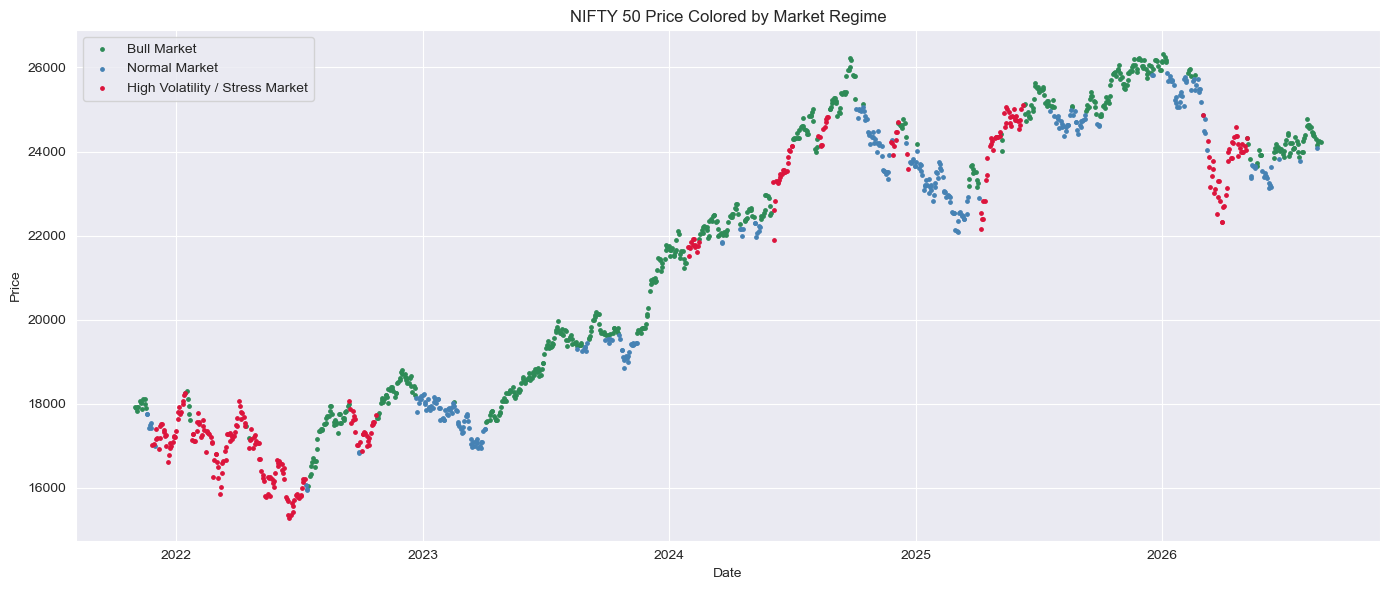

In [6]:
# Visualize NIFTY 50 price colored by regime
regime_colors = {
    "Bull Market": "seagreen",
    "Normal Market": "steelblue",
    "High Volatility / Stress Market": "crimson",
}

fig, ax = plt.subplots(figsize=(14, 6))
nifty_regime = regimes["NIFTY 50"]
nifty_price_aligned = prices["NIFTY 50"].reindex(nifty_regime.index)
for label, color in regime_colors.items():
    mask = nifty_regime == label
    ax.scatter(nifty_price_aligned.index[mask], nifty_price_aligned[mask],
               s=6, color=color, label=label)

ax.set_title("NIFTY 50 Price Colored by Market Regime")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Correlation Matrix

How closely do the three indices move together across the full period?


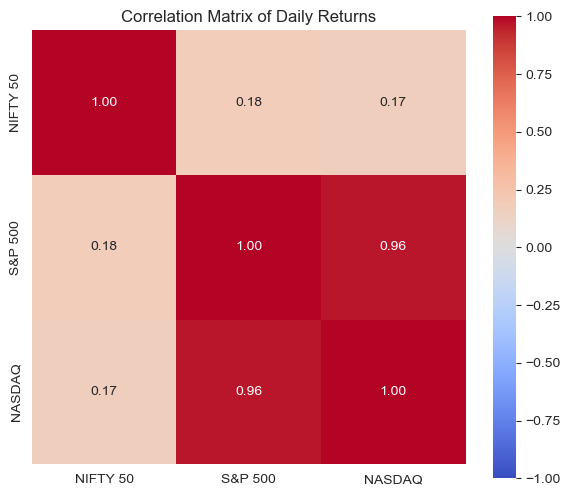

,NIFTY 50,S&P 500,NASDAQ
NIFTY 50,1.00,0.18,0.17
S&P 500,0.18,1.00,0.96
NASDAQ,0.17,0.96,1.00


In [7]:
correlation_matrix = daily_returns.corr()

plt.figure(figsize=(7, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix of Daily Returns")
plt.show()

correlation_matrix.round(2)


## 6. Rolling Correlation (30-Day)

A single correlation number hides how the relationship between markets changes
over time. A 30-day **rolling correlation** shows this evolving relationship.


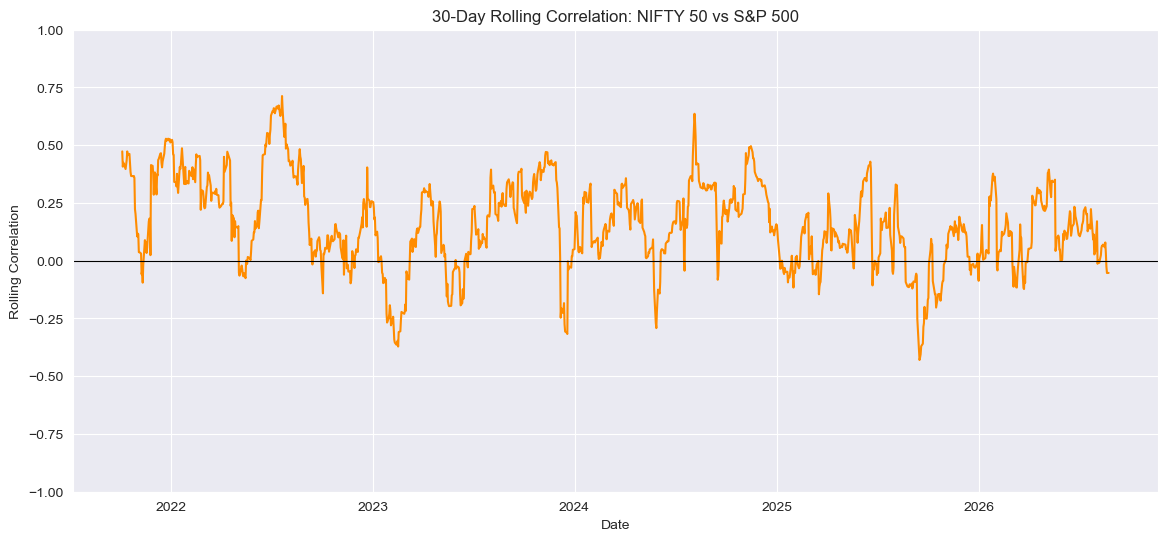

In [8]:
rolling_corr_nifty_sp500 = (
    daily_returns["NIFTY 50"].rolling(30).corr(daily_returns["S&P 500"])
)

plt.figure(figsize=(14, 6))
plt.plot(rolling_corr_nifty_sp500.index, rolling_corr_nifty_sp500, color="darkorange")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("30-Day Rolling Correlation: NIFTY 50 vs S&P 500")
plt.xlabel("Date")
plt.ylabel("Rolling Correlation")
plt.ylim(-1, 1)
plt.show()


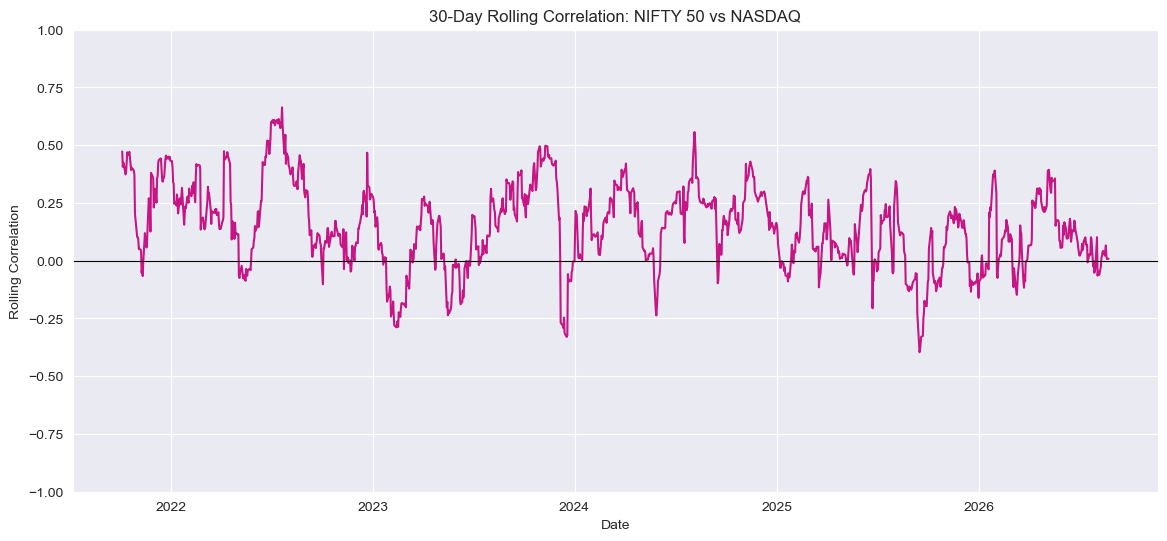

In [9]:
rolling_corr_nifty_nasdaq = (
    daily_returns["NIFTY 50"].rolling(30).corr(daily_returns["NASDAQ"])
)

plt.figure(figsize=(14, 6))
plt.plot(rolling_corr_nifty_nasdaq.index, rolling_corr_nifty_nasdaq, color="mediumvioletred")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("30-Day Rolling Correlation: NIFTY 50 vs NASDAQ")
plt.xlabel("Date")
plt.ylabel("Rolling Correlation")
plt.ylim(-1, 1)
plt.show()


## 7. Rolling Volatility

The same 30-day rolling window, but measuring each index's own annualized
volatility instead of correlation between indices.


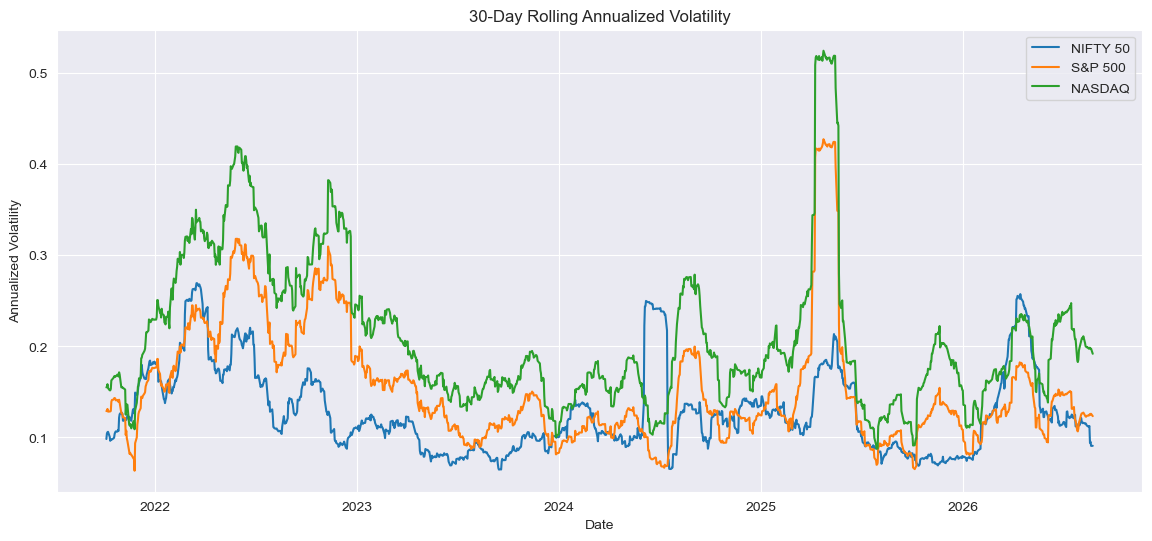

In [10]:
rolling_volatility = daily_returns.rolling(30).std() * np.sqrt(252)

plt.figure(figsize=(14, 6))
for name in indices:
    plt.plot(rolling_volatility.index, rolling_volatility[name], label=name)
plt.title("30-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.show()


## 8. Distribution of Returns

How are daily returns distributed for each index? We compare the actual
histogram against a normal distribution with the same mean and standard
deviation, and report skewness and kurtosis (using `scipy.stats`) to describe
how the real distribution differs from a normal one.


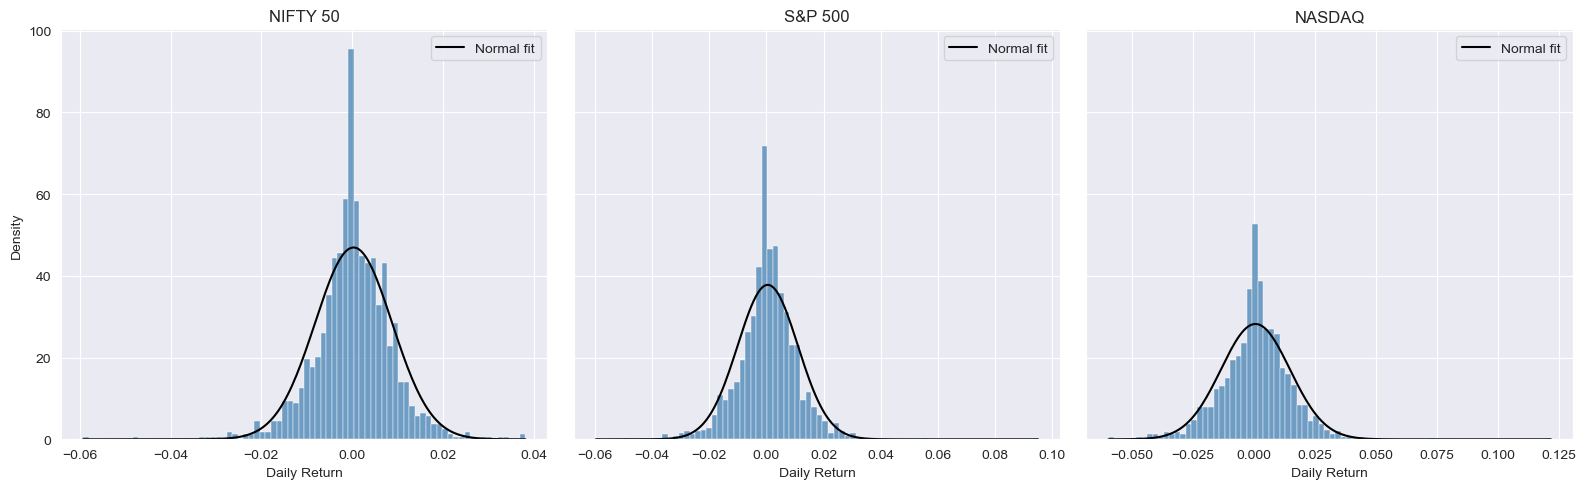

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, name in zip(axes, indices):
    returns = daily_returns[name]
    sns.histplot(returns, bins=80, stat="density", color="steelblue", ax=ax)

    x = np.linspace(returns.min(), returns.max(), 200)
    normal_curve = stats.norm.pdf(x, returns.mean(), returns.std())
    ax.plot(x, normal_curve, color="black", linewidth=1.5, label="Normal fit")

    ax.set_title(name)
    ax.set_xlabel("Daily Return")
    ax.legend()

plt.tight_layout()
plt.show()


In [12]:
return_stats = pd.DataFrame({
    "Mean": daily_returns.mean(),
    "Std Dev": daily_returns.std(),
    "Skewness": daily_returns.apply(stats.skew),
    "Kurtosis": daily_returns.apply(stats.kurtosis),
})
return_stats.round(4)


,Mean,Std Dev,Skewness,Kurtosis
NIFTY 50,0.0003,0.0085,-0.3854,4.0742
S&P 500,0.0005,0.0106,0.1682,7.2540
NASDAQ,0.0005,0.0141,0.2161,5.4076


## 9. Positive vs Negative Days

A simple way to gauge overall sentiment: what fraction of trading days were
gains vs. losses?


In [13]:
day_counts = pd.DataFrame({
    "Positive Days": (daily_returns > 0).sum(),
    "Negative Days": (daily_returns < 0).sum(),
    "Flat Days": (daily_returns == 0).sum(),
})
day_counts["Positive Day %"] = (day_counts["Positive Days"] / len(daily_returns) * 100).round(1)

day_counts


,Positive Days,Negative Days,Flat Days,Positive Day %
NIFTY 50,651,583,63,50.2
S&P 500,669,584,44,51.6
NASDAQ,680,573,44,52.4


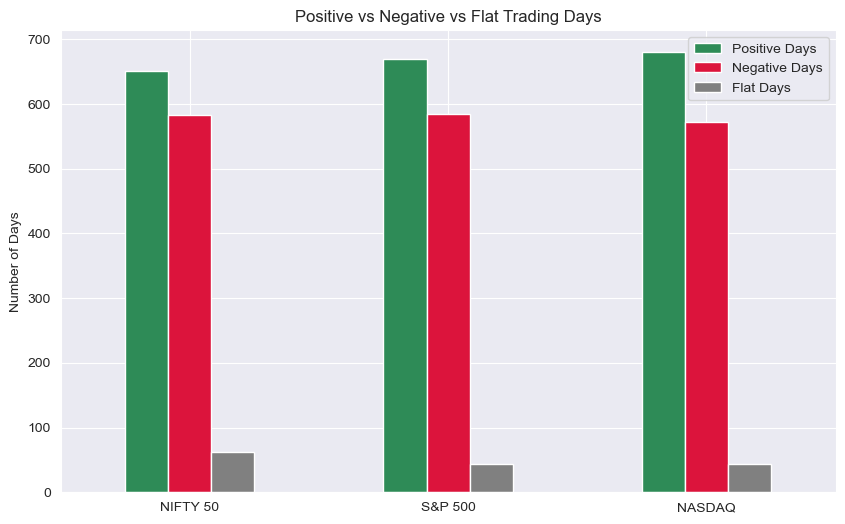

In [14]:
day_counts[["Positive Days", "Negative Days", "Flat Days"]].plot(
    kind="bar", figsize=(10, 6), color=["seagreen", "crimson", "gray"]
)
plt.title("Positive vs Negative vs Flat Trading Days")
plt.ylabel("Number of Days")
plt.xticks(rotation=0)
plt.show()


## 10. Drawdowns

Drawdown measures how far each index has fallen from its most recent peak.
The maximum drawdown is the single worst peak-to-trough decline over the period.


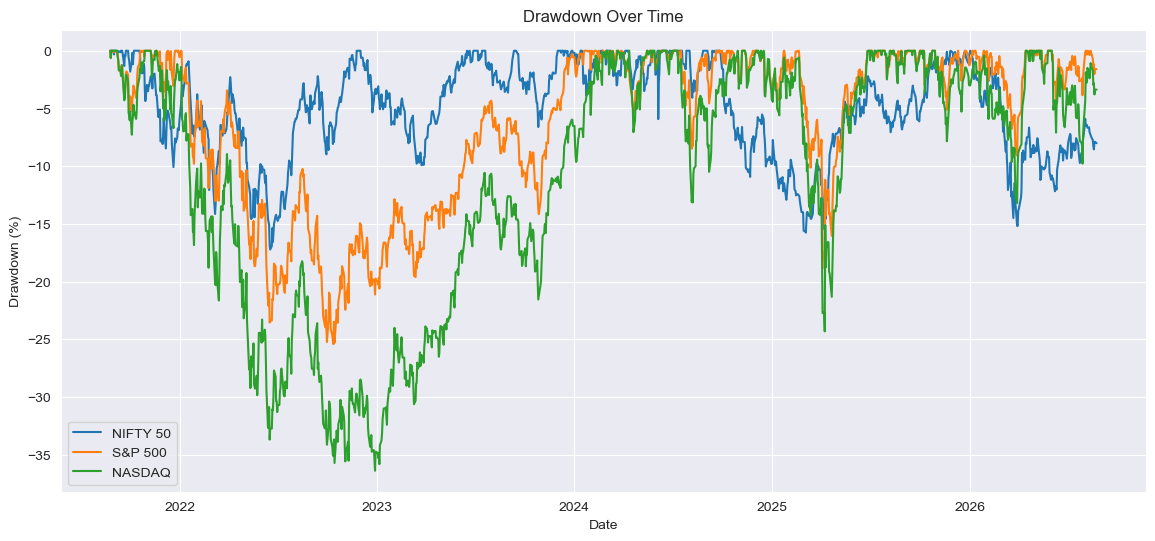

Maximum drawdown per index (%):


NASDAQ     -36.40
S&P 500    -25.43
NIFTY 50   -17.23
dtype: float64

In [15]:
growth = (1 + daily_returns).cumprod()
running_max = growth.cummax()
drawdown = (growth - running_max) / running_max

plt.figure(figsize=(14, 6))
for name in indices:
    plt.plot(drawdown.index, drawdown[name] * 100, label=name)
plt.title("Drawdown Over Time")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.legend()
plt.show()

max_drawdown = (drawdown.min() * 100).round(2).sort_values()
print("Maximum drawdown per index (%):")
max_drawdown


## 11. Summary

Pulling the key numbers together into one table.


In [16]:
summary = pd.DataFrame({
    "Annualized Volatility": (daily_returns.std() * np.sqrt(252)).round(4),
    "Max Drawdown (%)": max_drawdown.round(2),
    "Positive Day %": day_counts["Positive Day %"],
    "Skewness": return_stats["Skewness"].round(3),
    "% Days in Stress Regime": (regime_counts.loc["High Volatility / Stress Market"] / regime_counts.sum() * 100).round(1),
})
summary


,Annualized Volatility,Max Drawdown (%),Positive Day %,Skewness,% Days in Stress Regime
NASDAQ,0.2243,-36.40,52.4,0.216,25.5
NIFTY 50,0.1349,-17.23,50.2,-0.385,25.5
S&P 500,0.1675,-25.43,51.6,0.168,25.5
